<a href="https://colab.research.google.com/github/sinakian/ai-lab-pumpkin-seeds/blob/pavel-rf-model/Pumpkin_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMPORT

In [2]:
!pip install openpyxl

In [3]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import seaborn as sns # library for making statistical and visualizations
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

from sklearn.metrics import confusion_matrix

# DATASET

In [4]:
import pandas as pd

dataset_url ="https://github.com/sinakian/ai-lab-pumpkin-seeds/raw/refs/heads/main/Pumpkin_Seeds_Dataset.xlsx"

data = pd.read_excel(dataset_url)

In [5]:
data.shape

(2500, 13)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               2500 non-null   int64  
 1   Perimeter          2500 non-null   float64
 2   Major_Axis_Length  2500 non-null   float64
 3   Minor_Axis_Length  2500 non-null   float64
 4   Convex_Area        2500 non-null   int64  
 5   Equiv_Diameter     2500 non-null   float64
 6   Eccentricity       2500 non-null   float64
 7   Solidity           2500 non-null   float64
 8   Extent             2500 non-null   float64
 9   Roundness          2500 non-null   float64
 10  Aspect_Ration      2500 non-null   float64
 11  Compactness        2500 non-null   float64
 12  Class              2500 non-null   object 
dtypes: float64(10), int64(2), object(1)
memory usage: 254.0+ KB


In [7]:
data.head()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Convex_Area,Equiv_Diameter,Eccentricity,Solidity,Extent,Roundness,Aspect_Ration,Compactness,Class
0,56276,888.242,326.1485,220.2388,56831,267.6805,0.7376,0.9902,0.7453,0.8963,1.4809,0.8207,Çerçevelik
1,76631,1068.146,417.1932,234.2289,77280,312.3614,0.8275,0.9916,0.7151,0.8440,1.7811,0.7487,Çerçevelik
2,71623,1082.987,435.8328,211.0457,72663,301.9822,0.8749,0.9857,0.7400,0.7674,2.0651,0.6929,Çerçevelik
3,66458,992.051,381.5638,222.5322,67118,290.8899,0.8123,0.9902,0.7396,0.8486,1.7146,0.7624,Çerçevelik
4,66107,998.146,383.8883,220.4545,67117,290.1207,0.8187,0.9850,0.6752,0.8338,1.7413,0.7557,Çerçevelik


In [8]:
data.describe()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Convex_Area,Equiv_Diameter,Eccentricity,Solidity,Extent,Roundness,Aspect_Ration,Compactness
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,80658.220800,1130.279015,456.601840,225.794921,81508.084400,319.334230,0.860879,0.989492,0.693205,0.791533,2.041702,0.704121
std,13664.510228,109.256418,56.235704,23.297245,13764.092788,26.891920,0.045167,0.003494,0.060914,0.055924,0.315997,0.053067
min,47939.000000,868.485000,320.844600,152.171800,48366.000000,247.058400,0.492100,0.918600,0.468000,0.554600,1.148700,0.560800
25%,70765.000000,1048.829750,414.957850,211.245925,71512.000000,300.167975,0.831700,0.988300,0.658900,0.751900,1.801050,0.663475
50%,79076.000000,1123.672000,449.496600,224.703100,79872.000000,317.305350,0.863700,0.990300,0.713050,0.797750,1.984200,0.707700
75%,89757.500000,1203.340500,492.737650,240.672875,90797.750000,338.057375,0.897025,0.991500,0.740225,0.834325,2.262075,0.743500
max,136574.000000,1559.450000,661.911300,305.818000,138384.000000,417.002900,0.948100,0.994400,0.829600,0.939600,3.144400,0.904900


In [9]:
data.nunique() # counts the number of different values

Area                 2424
Perimeter            2490
Major_Axis_Length    2499
Minor_Axis_Length    2497
Convex_Area          2445
Equiv_Diameter       2424
Eccentricity         1295
Solidity              166
Extent               1392
Roundness            1480
Aspect_Ration        2237
Compactness          1405
Class                   2
dtype: int64

In [10]:
data.isnull().sum()

Area                 0
Perimeter            0
Major_Axis_Length    0
Minor_Axis_Length    0
Convex_Area          0
Equiv_Diameter       0
Eccentricity         0
Solidity             0
Extent               0
Roundness            0
Aspect_Ration        0
Compactness          0
Class                0
dtype: int64

# DATA Preparation and EDA

In [11]:
X = data.drop(columns='Class')
y = data['Class']


In [12]:
data['Class'].value_counts(normalize=True)

Class
Çerçevelik       0.52
Ürgüp Sivrisi    0.48
Name: proportion, dtype: float64

In [13]:
# coding classes in numbers

encoder = LabelEncoder()
y = encoder.fit_transform(y) # revert 2 classes to 0/1
print(y)

[0 0 0 ... 1 1 1]


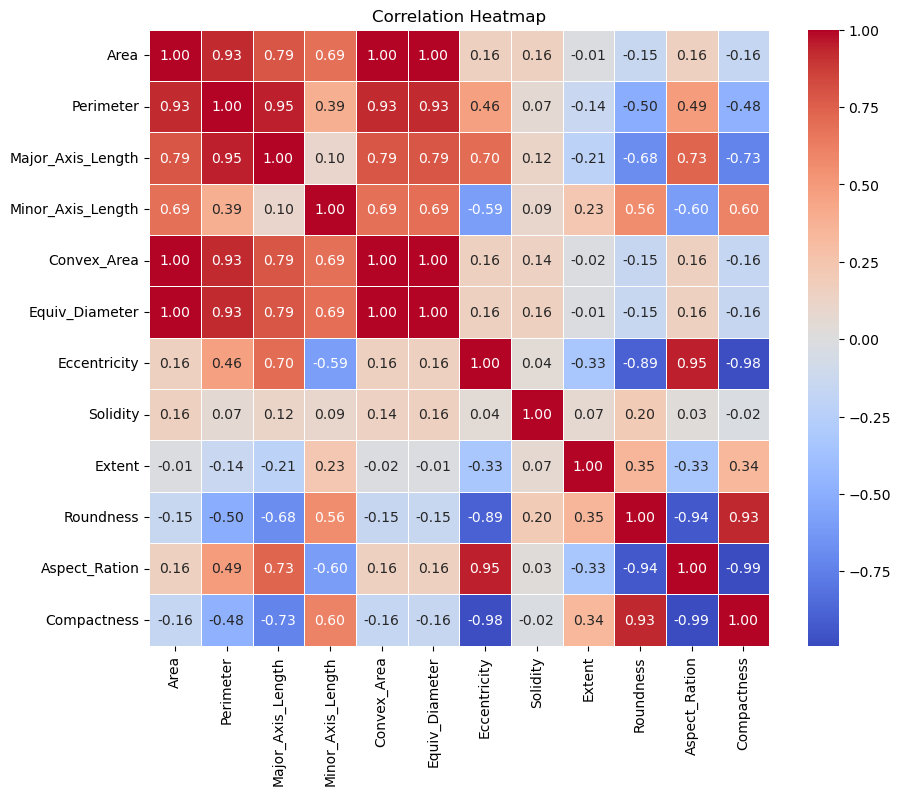

In [14]:
corr = data.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,      # show correlation values
    fmt=".2f",       # 2 decimal places
    cmap="coolwarm", # colors
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

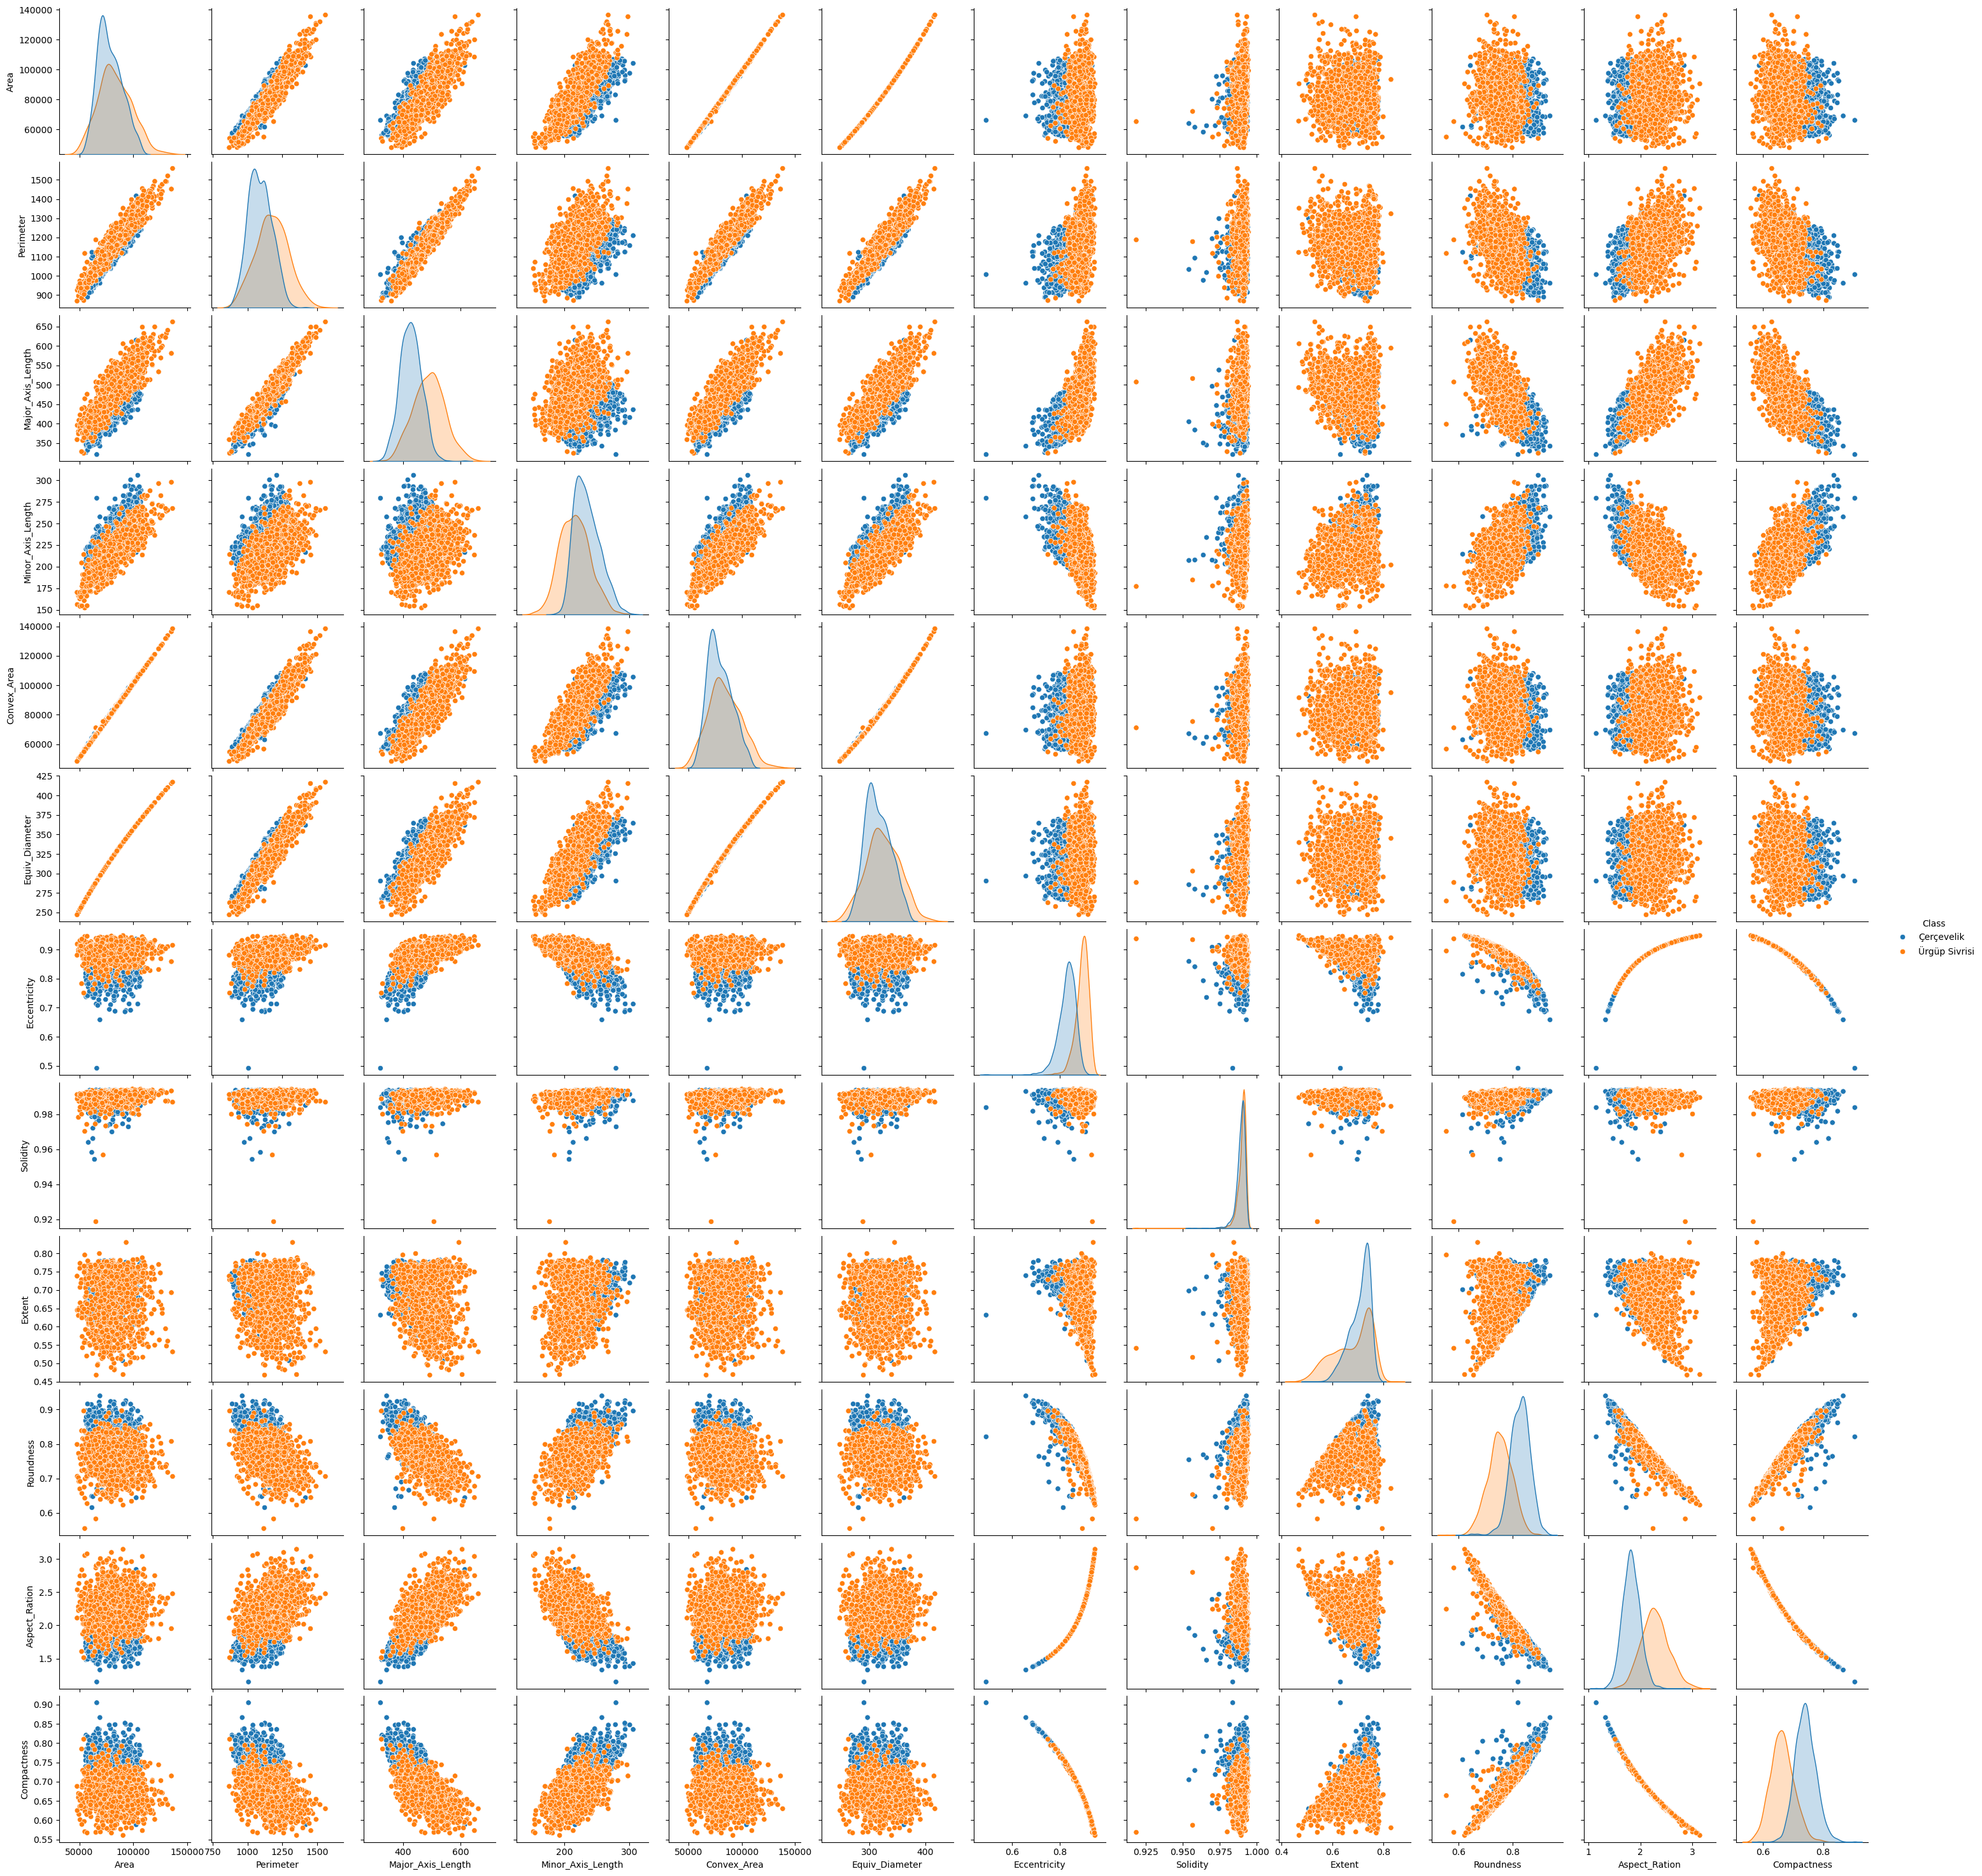

In [15]:
sns.pairplot(data, hue="Class")
plt.show()

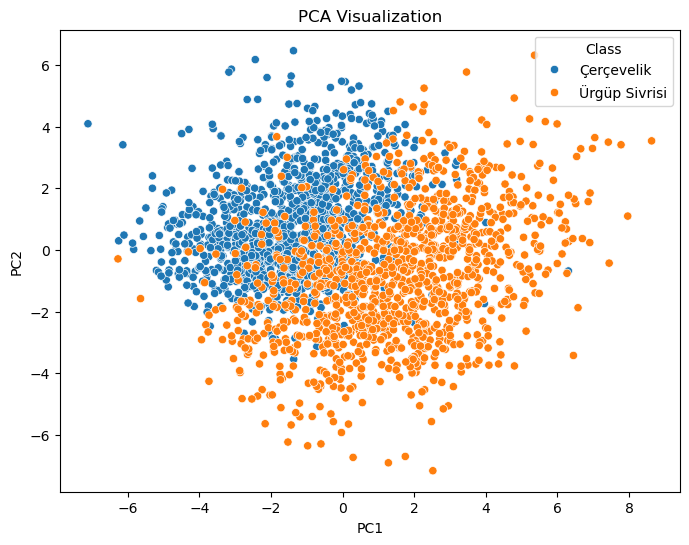

In [16]:

x = data.drop('Class', axis=1) # axis=1 - find in columns(horisontal ), find 'class'
y = data['Class']

scaler = StandardScaler() # x_scaled​=(x − mean)​/std
x_scaled = scaler.fit_transform(x)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Class"] = y

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Class")
plt.title("PCA Visualization")
plt.show()


# TRAIN

In [17]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    y,
    random_state=42, # same split every run
    stratify=y # same class proportions
)

# Without random


# *****

In [18]:
model = RandomForestClassifier()

In [19]:
model.fit(X_train , Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
Y_predict = model.predict( X_test )

In [21]:
accuracy = accuracy_score( Y_test , Y_predict )

print( 'Accuracy:', accuracy)

Accuracy: 0.8816


# *****

---



In [22]:
rf = RandomForestClassifier(
    random_state=42
)

In [23]:
# find best hyperparameters

parameters = {

    "n_estimators":[50,100,200,300],

    "max_depth":[3,5,10,None], # None - No depth limit

    "min_samples_split":[2,4,6], 

    "min_samples_leaf":[1,2,4] 

}

rf_search = RandomizedSearchCV( # creates and configures the RandomizedSearchCV object

    estimator=rf, # Use this Random Forest classifier

    param_distributions=parameters,

    n_iter=20, # only 20 combinations from all parameters

    cv=5, 

    scoring="accuracy", 

    random_state=42

)


rf_search.fit(
    X_train,
    Y_train
)

rf_search.best_params_ # contains the best Random Forest
# max_depth: Maximum tree depth
# min_samples_split: Minimum samples needed to split a node
# min_samples_leaf: Minimum samples required at leaf node

{'n_estimators': 100,
 'min_samples_split': 2,
 'min_samples_leaf': 4,
 'max_depth': 10}

In [24]:
tree = RandomForestClassifier(**rf_search.best_params_, random_state=42) # The ** operator unpacks the dictionary into keyword arguments.

In [25]:
tree.fit(X_train, Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
print(tree.criterion)
print(tree.bootstrap)

gini
True


In [27]:
tree.oob_score

False

In [28]:
Y_pred = tree.predict(X_test)

# EVALUATION

In [29]:
accuracy = accuracy_score(
    Y_test,
    Y_pred
)

print(accuracy) # compare true labels (Y_test) vs. prediction labels (Y_pred)

0.888


In [30]:
cassif_report = classification_report(
    Y_test,
    Y_pred
)

print('Test_set', cassif_report)

###
# Macro average
# =
# average of class scores

# Weighted average
# =
# average of class scores
# +
# considers class sizes
###

Test_set                precision    recall  f1-score   support

   Çerçevelik       0.87      0.93      0.90       325
Ürgüp Sivrisi       0.91      0.85      0.88       300

     accuracy                           0.89       625
    macro avg       0.89      0.89      0.89       625
 weighted avg       0.89      0.89      0.89       625



In [31]:
conf_matrix = confusion_matrix(
    Y_test,
    Y_pred
)

print(conf_matrix) # [TN FP][FN TP]
###
# 302 TN → Class 0 correctly predicted as Class 0.
# 23 FP → Class 0 incorrectly predicted as Class 1.
# 45 FN → Class 1 incorrectly predicted as Class 0.
# 255 TP → Class 1 correctly predicted as Class 1.
###

[[301  24]
 [ 46 254]]


# VISUALIZATION

In [32]:
from sklearn import tree as treefig

[Text(0.49613575268817206, 0.9545454545454546, 'x[9] <= 0.785\ngini = 0.498\nsamples = 1184\nvalue = [998, 877]'),
 Text(0.24865591397849462, 0.8636363636363636, 'x[9] <= 0.772\ngini = 0.235\nsamples = 508\nvalue = [107, 680]'),
 Text(0.37239583333333337, 0.9090909090909092, 'True  '),
 Text(0.11559139784946236, 0.7727272727272727, 'x[2] <= 393.862\ngini = 0.143\nsamples = 417\nvalue = [50, 596]'),
 Text(0.06451612903225806, 0.6818181818181818, 'x[6] <= 0.814\ngini = 0.298\nsamples = 8\nvalue = [9, 2]'),
 Text(0.053763440860215055, 0.5909090909090909, 'gini = 0.0\nsamples = 4\nvalue = [7, 0]'),
 Text(0.07526881720430108, 0.5909090909090909, 'gini = 0.5\nsamples = 4\nvalue = [2, 2]'),
 Text(0.16666666666666666, 0.6818181818181818, 'x[11] <= 0.68\ngini = 0.121\nsamples = 409\nvalue = [41, 594]'),
 Text(0.0967741935483871, 0.5909090909090909, 'x[6] <= 0.894\ngini = 0.053\nsamples = 374\nvalue = [16, 569]'),
 Text(0.053763440860215055, 0.5, 'x[6] <= 0.893\ngini = 0.193\nsamples = 48\nvalue

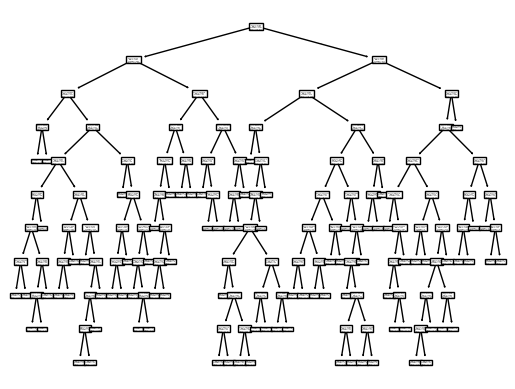

In [33]:
treefig.plot_tree(tree.estimators_[0])

Graphviz executable not found. Rendering fallback tree plot with sklearn.


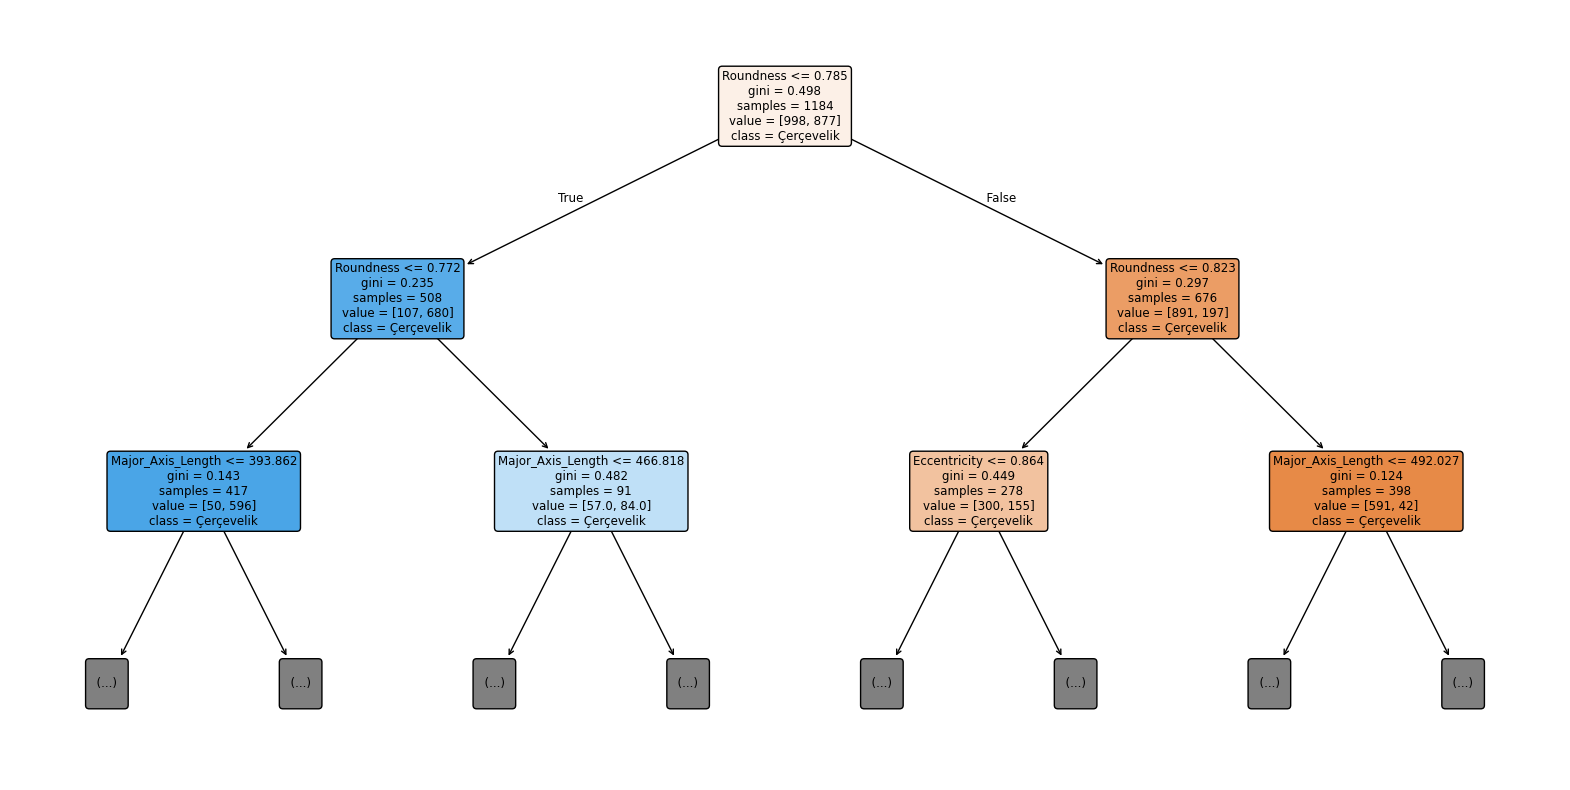

In [34]:
import shutil
from sklearn import tree as treefig
from sklearn.tree import export_graphviz
import graphviz
import matplotlib.pyplot as plt

if shutil.which("dot") is None:
    print("Graphviz executable not found. Rendering fallback tree plot with sklearn.")
    plt.figure(figsize=(20, 10))
    treefig.plot_tree(tree.estimators_[0],
                      feature_names=X.columns,
                      class_names=[str(a) for a in y],
                      filled=True, rounded=True,
                      max_depth=2)
    plt.show()
else:
    dot_data = export_graphviz(tree.estimators_[0], out_file=None,
                               feature_names=X.columns,
                               class_names=[str(a) for a in y],
                               filled=True, rounded=True,
                               max_depth=2,
                               impurity=False,
                               proportion=True)
    graph = graphviz.Source(dot_data)
    display(graph)

Graphviz executable not found. Rendering fallback tree plot with sklearn.


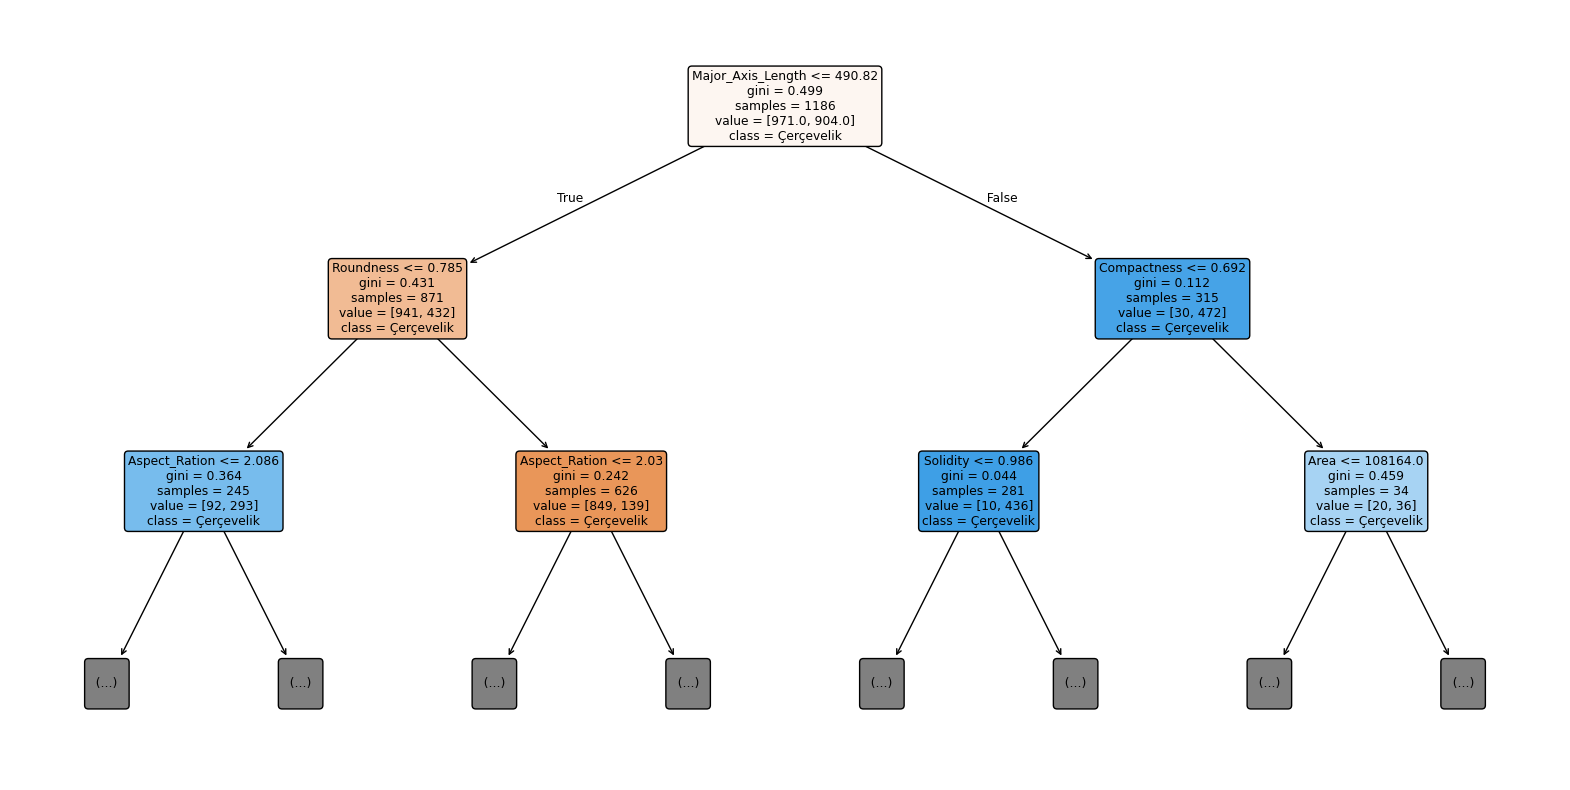

In [35]:
import shutil
from sklearn import tree as treefig
from sklearn.tree import export_graphviz
import graphviz
import matplotlib.pyplot as plt

if shutil.which("dot") is None:
    print("Graphviz executable not found. Rendering fallback tree plot with sklearn.")
    plt.figure(figsize=(20, 10))
    treefig.plot_tree(tree.estimators_[1],
                      feature_names=X.columns,
                      class_names=[str(a) for a in y],
                      filled=True, rounded=True,
                      max_depth=2)
    plt.show()
else:
    dot_data = export_graphviz(tree.estimators_[1], out_file=None,
                               feature_names=X.columns,
                               class_names=[str(a) for a in y],
                               filled=True, rounded=True,
                               max_depth=2,
                               impurity=False,
                               proportion=True)
    graph = graphviz.Source(dot_data)
    display(graph)

Graphviz executable not found. Rendering fallback tree plot with sklearn.


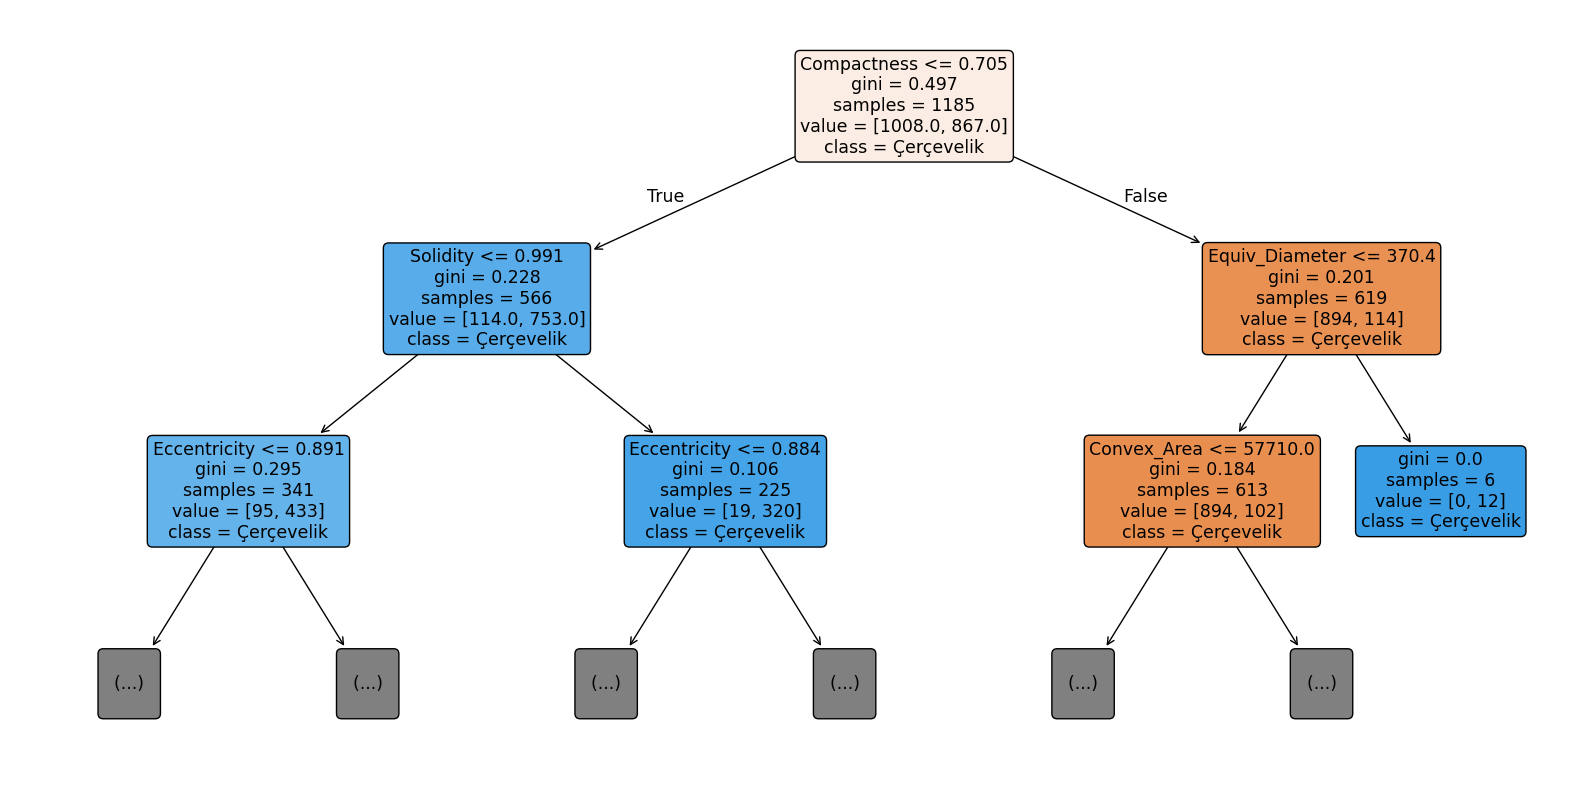

In [36]:
import shutil
from sklearn import tree as treefig
from sklearn.tree import export_graphviz
import graphviz
import matplotlib.pyplot as plt

if shutil.which("dot") is None:
    print("Graphviz executable not found. Rendering fallback tree plot with sklearn.")
    plt.figure(figsize=(20, 10))
    treefig.plot_tree(tree.estimators_[72],
                      feature_names=X.columns,
                      class_names=[str(a) for a in y],
                      filled=True, rounded=True,
                      max_depth=2)
    plt.show()
else:
    dot_data = export_graphviz(tree.estimators_[72], out_file=None,
                               feature_names=X.columns,
                               class_names=[str(a) for a in y],
                               filled=True, rounded=True,
                               max_depth=2,
                               impurity=False,
                               proportion=True)
    graph = graphviz.Source(dot_data)
    display(graph)

# Logistic Regression

In [37]:
scaler = StandardScaler()
X_scaled_LR = scaler.fit_transform(X)

In [38]:
X_train_LR, X_test_LR, Y_train_LR, Y_test_LR = train_test_split(
    X_scaled_LR,
    y,
    random_state=42,
    stratify=y
)

In [39]:
from sklearn.model_selection import RandomizedSearchCV

parameters = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["lbfgs", "liblinear"],
    "penalty": ["l2"]
}

In [40]:
lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [41]:
lr_search = RandomizedSearchCV(
    estimator=lr,
    param_distributions=parameters,
    n_iter=10,
    cv=5,
    scoring="accuracy",
    random_state=42
)

In [42]:
lr_search.fit(X_train_LR, Y_train_LR)

best_lr = lr_search.best_estimator_

In [43]:
print(lr_search.best_params_)

{'solver': 'lbfgs', 'penalty': 'l2', 'C': 100}


In [44]:
Y_pred_LR = best_lr.predict(X_test_LR)

In [45]:
print("Accuracy:", accuracy_score(Y_test_LR, Y_pred_LR))
print(classification_report(Y_test_LR, Y_pred_LR))

Accuracy: 0.8768
               precision    recall  f1-score   support

   Çerçevelik       0.86      0.91      0.88       325
Ürgüp Sivrisi       0.90      0.84      0.87       300

     accuracy                           0.88       625
    macro avg       0.88      0.88      0.88       625
 weighted avg       0.88      0.88      0.88       625



In [46]:
conf_matrix = confusion_matrix(
    Y_test_LR,
    Y_pred_LR
)

print(conf_matrix) # [TN FP][FN TP]

[[296  29]
 [ 48 252]]
